<a href="https://colab.research.google.com/github/ikabrain/UCS772-CV-NLP-Lab/blob/main/NLP_assign3/NLP_assign3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 - Exploratory Data Analysis
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Introduction
---

In [2]:
# Saving pickle file results from Assignment 2
!rm -rf pickle/
!wget -q -P pickle/ https://github.com/ikabrain/UCS772-CV-NLP-Lab/raw/refs/heads/main/NLP_assign2/pickle/dtm.pkl
!wget -q -P pickle/ https://github.com/ikabrain/UCS772-CV-NLP-Lab/raw/refs/heads/main/NLP_assign2/pickle/data_clean.pkl

In [3]:
# Read in the document-term matrix
data = pd.read_pickle("./pickle/dtm.pkl")
data = data.transpose()
data.head()

,ali,anthony,bill,bo,dave,hasan,jim,joe,john,louis,mike,ricky
aaaaah,0,0,1,0,0,0,0,0,0,0,0,0
aaaaahhhhhhh,0,0,0,1,0,0,0,0,0,0,0,0
aaaaauuugghhhhhh,0,0,0,1,0,0,0,0,0,0,0,0
aaaahhhhh,0,0,0,1,0,0,0,0,0,0,0,0
aaah,0,0,0,0,1,0,0,0,0,0,0,0


In [4]:
# Read in the cleaned data
data_clean = pd.read_pickle('./pickle/data_clean.pkl')
data_clean.head()

,transcript
ali,ladies and gentlemen please welcome to the sta...
anthony,thank you thank you thank you san francisco th...
bill,all right thank you thank you very much thank...
bo,bo what old macdonald had a farm e i e i o and...
dave,this is dave he tells dirty jokes for a living...


After the data cleaning step where we put our data into a few standard formats, the next step is to take a look at the data and see if what we're looking at makes sense. Before applying any fancy algorithms, it's always important to explore the data first.

When working with numerical data, some of the exploratory data analysis (EDA) techniques we can use include finding the average of the data set, the distribution of the data, the most common values, etc. The idea is the same when working with text data. We are going to find some more obvious patterns with EDA before identifying the hidden patterns with machines learning (ML) techniques. We are going to look at the following for each comedian:

1. **Most common words** - find these and create word clouds
2. **Size of vocabulary** - look number of unique words and also how quickly someone speaks
3. **Amount of profanity** - most common terms

## Q1: Most Common Words
---

 - Find the most common words and create word clouds
    - Find the top 30 words and create word clouds (by looking at these top words, you can see that some of them have very little meaning and could be added to a stop words list)
    - Update by excluding new stop words and recreate the word cloud

### Analysis

In [5]:
# Find the top 30 words said by each comedian
top_dict = {}
for c in data.columns:
    top = data[c].sort_values(ascending=False).head(30)
    top_dict[c]= list(zip(top.index, top.values))

top_dict

{'ali': [('like', np.int64(126)),
  ('im', np.int64(74)),
  ('know', np.int64(65)),
  ('just', np.int64(64)),
  ('dont', np.int64(61)),
  ('shit', np.int64(34)),
  ('thats', np.int64(34)),
  ('youre', np.int64(31)),
  ('gonna', np.int64(28)),
  ('ok', np.int64(26)),
  ('lot', np.int64(24)),
  ('gotta', np.int64(21)),
  ('wanna', np.int64(21)),
  ('oh', np.int64(21)),
  ('husband', np.int64(20)),
  ('right', np.int64(19)),
  ('time', np.int64(19)),
  ('got', np.int64(19)),
  ('cause', np.int64(18)),
  ('women', np.int64(17)),
  ('day', np.int64(17)),
  ('people', np.int64(16)),
  ('pregnant', np.int64(15)),
  ('need', np.int64(14)),
  ('god', np.int64(14)),
  ('hes', np.int64(14)),
  ('tell', np.int64(13)),
  ('yeah', np.int64(13)),
  ('dude', np.int64(12)),
  ('really', np.int64(12))],
 'anthony': [('im', np.int64(60)),
  ('like', np.int64(50)),
  ('know', np.int64(39)),
  ('dont', np.int64(38)),
  ('got', np.int64(34)),
  ('joke', np.int64(34)),
  ('thats', np.int64(31)),
  ('said', n

In [6]:
# Print the top 15 words said by each comedian
for comedian, top_words in top_dict.items():
    print(comedian)
    print(', '.join([word for word, count in top_words[0:14]]))
    print('---')

ali
like, im, know, just, dont, shit, thats, youre, gonna, ok, lot, gotta, wanna, oh
---
anthony
im, like, know, dont, got, joke, thats, said, anthony, day, just, say, guys, people
---
bill
like, just, right, im, know, dont, gonna, got, fucking, yeah, shit, youre, thats, dude
---
bo
know, like, im, love, think, bo, just, stuff, repeat, dont, yeah, want, right, cos
---
dave
like, know, said, just, im, shit, people, didnt, dont, ahah, time, thats, fuck, fucking
---
hasan
like, im, know, dont, dad, youre, just, going, thats, want, got, love, shes, hasan
---
jim
like, im, dont, right, fucking, just, went, know, youre, people, thats, day, oh, going
---
joe
like, people, just, dont, im, fucking, fuck, thats, gonna, theyre, know, youre, think, shit
---
john
like, know, just, dont, said, clinton, im, thats, right, youre, little, hey, got, time
---
louis
like, just, know, dont, thats, im, youre, life, people, thing, gonna, hes, cause, theres
---
mike
like, im, know, said, just, dont, thats, thi

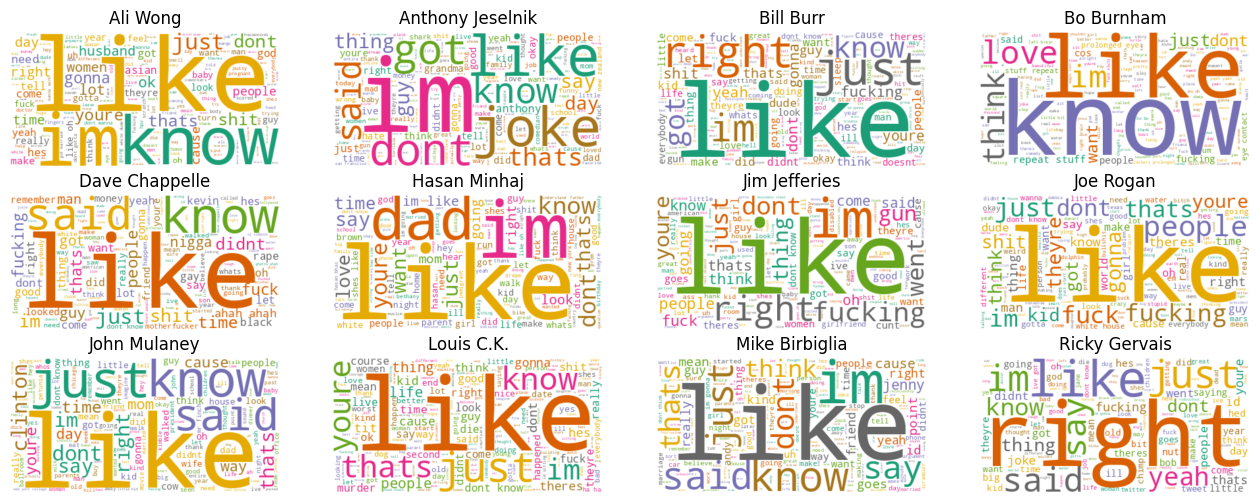

In [7]:
# Word clouds using only the default English stop words (before adding the new ones)
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

wc_before = WordCloud(stopwords=ENGLISH_STOP_WORDS, background_color="white", colormap="Dark2",
                       max_font_size=150, random_state=42)

plt.rcParams['figure.figsize'] = [16, 6]

full_names = ['Ali Wong', 'Anthony Jeselnik', 'Bill Burr', 'Bo Burnham', 'Dave Chappelle', 'Hasan Minhaj',
              'Jim Jefferies', 'Joe Rogan', 'John Mulaney', 'Louis C.K.', 'Mike Birbiglia', 'Ricky Gervais']

for index, comedian in enumerate(data.columns):
    wc_before.generate(data_clean.transcript[comedian])

    plt.subplot(3, 4, index+1)
    plt.imshow(wc_before, interpolation="bilinear")
    plt.axis("off")
    plt.title(full_names[index])

plt.show()

**NOTE:** At this point, we could go on and create word clouds. However, by looking at these top words, you can see that some of them have very little meaning and could be added to a stop words list, so let's do just that.



In [8]:
# Look at the most common top words --> add them to the stop word list
from collections import Counter

# Let's first pull out the top 30 words for each comedian
words = []
for comedian in data.columns:
    top = [word for (word, count) in top_dict[comedian]]
    for t in top:
        words.append(t)

words

['like',
 'im',
 'know',
 'just',
 'dont',
 'shit',
 'thats',
 'youre',
 'gonna',
 'ok',
 'lot',
 'gotta',
 'wanna',
 'oh',
 'husband',
 'right',
 'time',
 'got',
 'cause',
 'women',
 'day',
 'people',
 'pregnant',
 'need',
 'god',
 'hes',
 'tell',
 'yeah',
 'dude',
 'really',
 'im',
 'like',
 'know',
 'dont',
 'got',
 'joke',
 'thats',
 'said',
 'anthony',
 'day',
 'just',
 'say',
 'guys',
 'people',
 'tell',
 'youre',
 'right',
 'grandma',
 'time',
 'think',
 'thing',
 'school',
 'yeah',
 'good',
 'jokes',
 'did',
 'baby',
 'ive',
 'gonna',
 'okay',
 'like',
 'just',
 'right',
 'im',
 'know',
 'dont',
 'gonna',
 'got',
 'fucking',
 'yeah',
 'shit',
 'youre',
 'thats',
 'dude',
 'think',
 'fuck',
 'want',
 'people',
 'did',
 'hes',
 'guy',
 'didnt',
 'make',
 'come',
 'thing',
 'going',
 'theyre',
 'let',
 'theres',
 'doing',
 'know',
 'like',
 'im',
 'love',
 'think',
 'bo',
 'just',
 'stuff',
 'repeat',
 'dont',
 'yeah',
 'want',
 'right',
 'cos',
 'said',
 'eye',
 'fucking',
 'peop

In [9]:
# Let's aggregate this list and identify the most common words along with how many routines they occur in
Counter(words).most_common()

[('like', 12),
 ('im', 12),
 ('know', 12),
 ('just', 12),
 ('dont', 12),
 ('thats', 12),
 ('right', 12),
 ('people', 12),
 ('youre', 11),
 ('got', 10),
 ('time', 9),
 ('gonna', 8),
 ('think', 8),
 ('yeah', 7),
 ('said', 7),
 ('oh', 6),
 ('cause', 6),
 ('hes', 6),
 ('say', 6),
 ('fucking', 6),
 ('fuck', 6),
 ('shit', 5),
 ('day', 5),
 ('really', 5),
 ('thing', 5),
 ('good', 5),
 ('want', 5),
 ('going', 5),
 ('theyre', 5),
 ('theres', 5),
 ('did', 4),
 ('didnt', 4),
 ('dude', 3),
 ('guys', 3),
 ('ive', 3),
 ('man', 3),
 ('little', 3),
 ('life', 3),
 ('went', 3),
 ('ok', 2),
 ('lot', 2),
 ('gotta', 2),
 ('women', 2),
 ('tell', 2),
 ('joke', 2),
 ('guy', 2),
 ('make', 2),
 ('come', 2),
 ('love', 2),
 ('dad', 2),
 ('mom', 2),
 ('hey', 2),
 ('white', 2),
 ('goes', 2),
 ('kids', 2),
 ('real', 2),
 ('old', 2),
 ('mean', 2),
 ('id', 2),
 ('wanna', 1),
 ('husband', 1),
 ('pregnant', 1),
 ('need', 1),
 ('god', 1),
 ('anthony', 1),
 ('grandma', 1),
 ('school', 1),
 ('jokes', 1),
 ('baby', 1),
 ('o

In [10]:
# If more than half of the comedians have it as a top word, exclude it from the list
add_stop_words = [word for word, count in Counter(words).most_common() if count > 6]
add_stop_words

['like',
 'im',
 'know',
 'just',
 'dont',
 'thats',
 'right',
 'people',
 'youre',
 'got',
 'time',
 'gonna',
 'think',
 'yeah',
 'said']

In [11]:
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import CountVectorizer

# Add new stop words
stop_words = list(text.ENGLISH_STOP_WORDS.union(add_stop_words))

# Recreate document-term matrix
cv = CountVectorizer(stop_words=stop_words)
data_cv = cv.fit_transform(data_clean.transcript)
data_stop = pd.DataFrame(data_cv.toarray(), columns=cv.get_feature_names_out())
data_stop.index = data_clean.index

# Pickle it for later use
import pickle
pickle.dump(cv, open("pickle/cv_stop.pkl", "wb"))
data_stop.to_pickle("pickle/dtm_stop.pkl")

In [12]:
# Recreate the word clouds using the updated stop word list
# Terminal / Anaconda Prompt: conda install -c conda-forge wordcloud
from wordcloud import WordCloud

wc = WordCloud(stopwords=stop_words, background_color="white", colormap="Dark2",
               max_font_size=150, random_state=42)

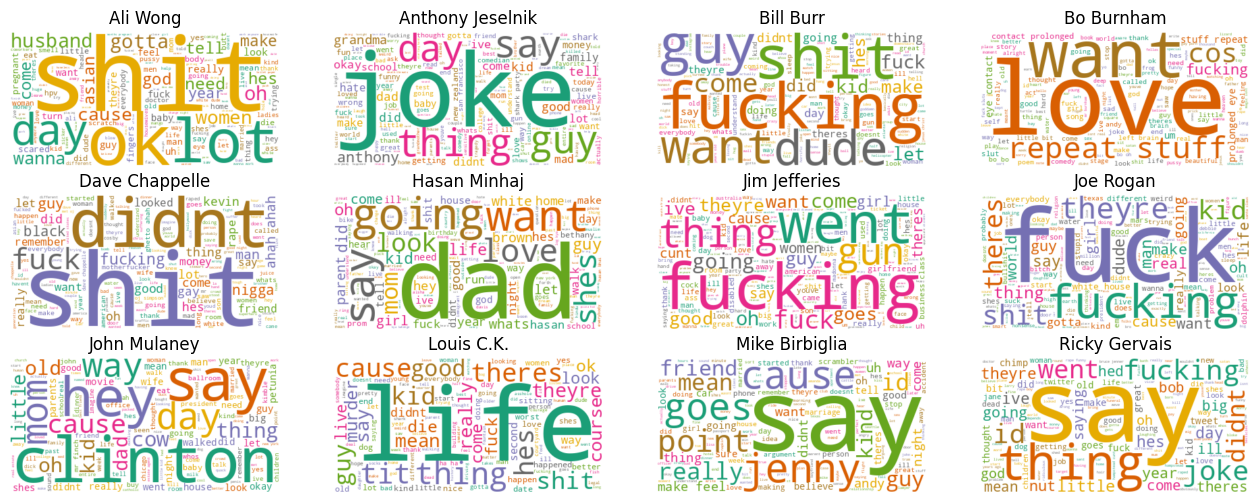

In [13]:
# Reset the output dimensions
plt.rcParams['figure.figsize'] = [16, 6]

# Create subplots for each comedian
for index, comedian in enumerate(data.columns):
    wc.generate(data_clean.transcript[comedian])

    plt.subplot(3, 4, index+1)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(full_names[index])

plt.show()

### Findings

* Ali Wong says the s-word a lot and talks about her husband. I guess that's funny.
* A lot of people use the F-word. Let's dig into that later.

## Q2: Size of Vocabulary
---

 - Size of vocabulary - look number of unique words and also how quickly someone speaks
    - Find the number of unique words that each comedian uses
    - Calculate the words per minute of each comedian see who talks the slowest and fastest (Comedy special run times from IMDB, in minutes i.e. Consider run_times = [60, 59, 80, 60, 67, 73, 77, 63, 62, 58, 76, 79]). Plot our findings.

### Analysis

In [14]:
# Find the number of unique words that each comedian uses

# Identify the non-zero items in the document-term matrix, meaning that the word occurs at least once
unique_list = []
for comedian in data.columns:
    uniques = data[comedian].to_numpy().nonzero()[0].size
    unique_list.append(uniques)

# Create a new dataframe that contains this unique word count
data_words = pd.DataFrame(list(zip(full_names, unique_list)), columns=['comedian', 'unique_words'])
data_unique_sort = data_words.sort_values(by='unique_words')
data_unique_sort

,comedian,unique_words
1,Anthony Jeselnik,984
9,Louis C.K.,1098
3,Bo Burnham,1272
6,Jim Jefferies,1313
0,Ali Wong,1341
8,John Mulaney,1391
4,Dave Chappelle,1404
7,Joe Rogan,1435
10,Mike Birbiglia,1494
5,Hasan Minhaj,1559


In [15]:
# Calculate the words per minute of each comedian

# Find the total number of words that a comedian uses
total_list = []
for comedian in data.columns:
    totals = sum(data[comedian])
    total_list.append(totals)

# Comedy special run times from IMDB, in minutes
run_times = [60, 59, 80, 60, 67, 73, 77, 63, 62, 58, 76, 79]

# Let's add some columns to our dataframe
data_words['total_words'] = total_list
data_words['run_times'] = run_times
data_words['words_per_minute'] = data_words['total_words'] / data_words['run_times']

# Sort the dataframe by words per minute to see who talks the slowest and fastest
data_wpm_sort = data_words.sort_values(by='words_per_minute')
data_wpm_sort

,comedian,unique_words,total_words,run_times,words_per_minute
1,Anthony Jeselnik,984,2905,59,49.237288
3,Bo Burnham,1272,3165,60,52.750000
0,Ali Wong,1341,3283,60,54.716667
9,Louis C.K.,1098,3332,58,57.448276
4,Dave Chappelle,1404,4094,67,61.104478
6,Jim Jefferies,1313,4764,77,61.870130
10,Mike Birbiglia,1494,4741,76,62.381579
11,Ricky Gervais,1633,4972,79,62.936709
8,John Mulaney,1391,4001,62,64.532258
5,Hasan Minhaj,1559,4777,73,65.438356


In [16]:
# See who talks the slowest and fastest
slowest = data_wpm_sort.iloc[0]
fastest = data_wpm_sort.iloc[-1]
print(f"Slowest talker: {slowest.comedian} ({slowest.words_per_minute:.1f} words/min)")
print(f"Fastest talker: {fastest.comedian} ({fastest.words_per_minute:.1f} words/min)")

Slowest talker: Anthony Jeselnik (49.2 words/min)
Fastest talker: Joe Rogan (72.7 words/min)


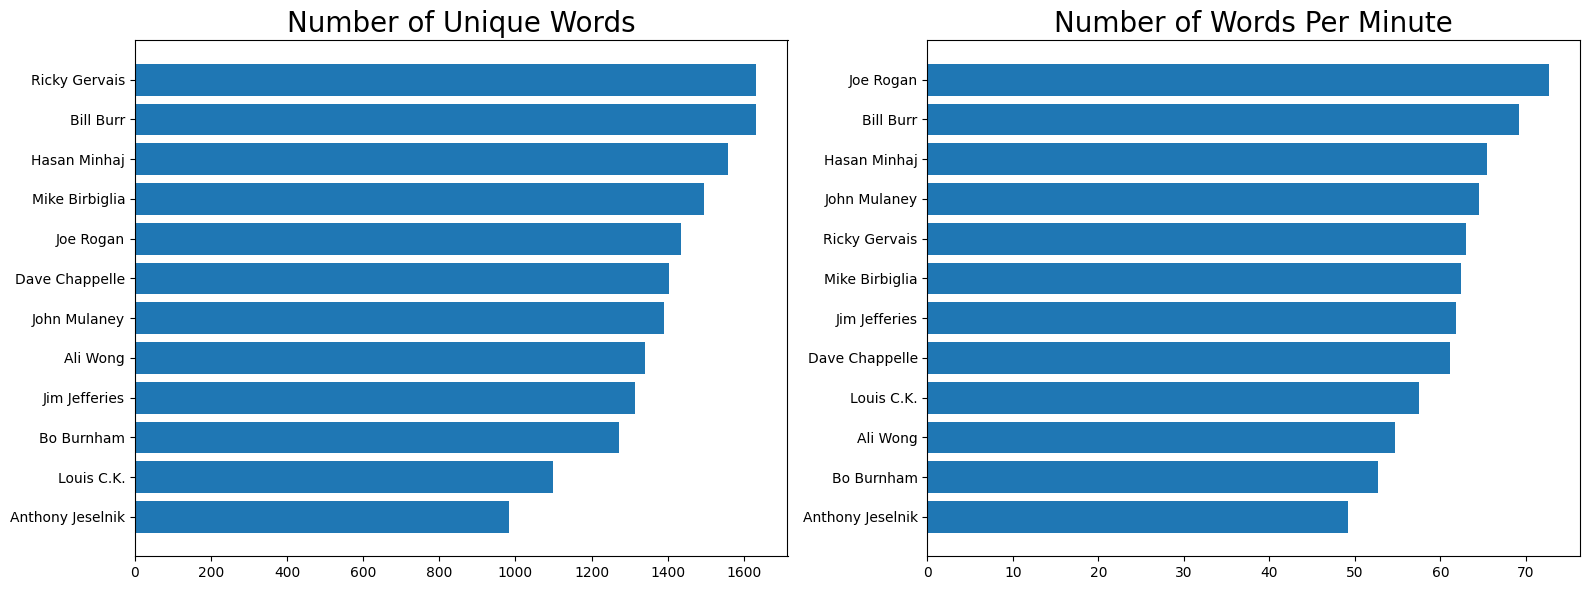

In [17]:
# Let's plot our findings
import numpy as np

y_pos = np.arange(len(data_words))

plt.subplot(1, 2, 1)
plt.barh(y_pos, data_unique_sort.unique_words, align='center')
plt.yticks(y_pos, data_unique_sort.comedian)
plt.title('Number of Unique Words', fontsize=20)

plt.subplot(1, 2, 2)
plt.barh(y_pos, data_wpm_sort.words_per_minute, align='center')
plt.yticks(y_pos, data_wpm_sort.comedian)
plt.title('Number of Words Per Minute', fontsize=20)

plt.tight_layout()
plt.show()

### Findings

* **Vocabulary**
   * Ricky Gervais (British comedy) and Bill Burr (podcast host) use a lot of words in their comedy
   * Louis C.K. (self-depricating comedy) and Anthony Jeselnik (dark humor) have a smaller vocabulary


* **Talking Speed**
   * Joe Rogan (blue comedy) and Bill Burr (podcast host) talk fast
   * Bo Burnham (musical comedy) and Anthony Jeselnik (dark humor) talk slow
   
Ali Wong is somewhere in the middle in both cases. Nothing too interesting here.

## Amount of Profanity
---

### Analysis

In [18]:
# Earlier I said we'd revisit profanity. Let's take a look at the most common words again.
Counter(words).most_common()

[('like', 12),
 ('im', 12),
 ('know', 12),
 ('just', 12),
 ('dont', 12),
 ('thats', 12),
 ('right', 12),
 ('people', 12),
 ('youre', 11),
 ('got', 10),
 ('time', 9),
 ('gonna', 8),
 ('think', 8),
 ('yeah', 7),
 ('said', 7),
 ('oh', 6),
 ('cause', 6),
 ('hes', 6),
 ('say', 6),
 ('fucking', 6),
 ('fuck', 6),
 ('shit', 5),
 ('day', 5),
 ('really', 5),
 ('thing', 5),
 ('good', 5),
 ('want', 5),
 ('going', 5),
 ('theyre', 5),
 ('theres', 5),
 ('did', 4),
 ('didnt', 4),
 ('dude', 3),
 ('guys', 3),
 ('ive', 3),
 ('man', 3),
 ('little', 3),
 ('life', 3),
 ('went', 3),
 ('ok', 2),
 ('lot', 2),
 ('gotta', 2),
 ('women', 2),
 ('tell', 2),
 ('joke', 2),
 ('guy', 2),
 ('make', 2),
 ('come', 2),
 ('love', 2),
 ('dad', 2),
 ('mom', 2),
 ('hey', 2),
 ('white', 2),
 ('goes', 2),
 ('kids', 2),
 ('real', 2),
 ('old', 2),
 ('mean', 2),
 ('id', 2),
 ('wanna', 1),
 ('husband', 1),
 ('pregnant', 1),
 ('need', 1),
 ('god', 1),
 ('anthony', 1),
 ('grandma', 1),
 ('school', 1),
 ('jokes', 1),
 ('baby', 1),
 ('o

In [19]:
# Let's isolate just these bad words
# The word 'f' is not present in the vocabulary. The intention is to sum 'fuck' and 'fucking'.
# We extract 'fuck', 'fucking', and 'shit' directly from the original 'data' DataFrame
# where words are the index and comedians are the columns.

f_word_counts = data.loc['fuck'] + data.loc['fucking']
s_word_counts = data.loc['shit']

# Create a new DataFrame for profanity counts
# The index will be the comedians, and columns will be 'f_word' and 's_word'.
data_profanity = pd.DataFrame({'f_word': f_word_counts, 's_word': s_word_counts})

data_profanity

,f_word,s_word
ali,16,34
anthony,15,9
bill,106,63
bo,37,6
dave,65,45
hasan,24,15
jim,115,20
joe,135,40
john,4,6
louis,21,25


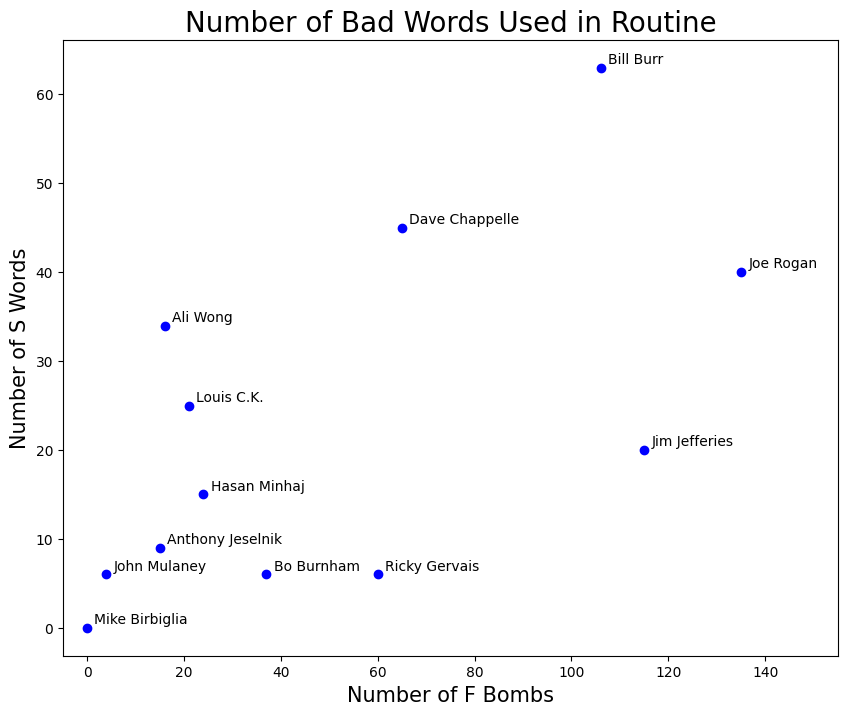

In [20]:
# Let's create a scatter plot of our findings
plt.rcParams['figure.figsize'] = [10, 8]

for i, comedian in enumerate(data_profanity.index):
    x = data_profanity.f_word.loc[comedian]
    y = data_profanity.s_word.loc[comedian]
    plt.scatter(x, y, color='blue')
    plt.text(x+1.5, y+0.5, full_names[i], fontsize=10)
    plt.xlim(-5, 155)

plt.title('Number of Bad Words Used in Routine', fontsize=20)
plt.xlabel('Number of F Bombs', fontsize=15)
plt.ylabel('Number of S Words', fontsize=15)

plt.show()

### Findings

* **Averaging 2 F-Bombs Per Minute!** - I don't like too much swearing, especially the f-word, which is probably why I've never heard of Bill Bur, Joe Rogan and Jim Jefferies.
* **Clean Humor** - It looks like profanity might be a good predictor of the type of comedy I like. Besides Ali Wong, my two other favorite comedians in this group are John Mulaney and Mike Birbiglia.

### Side Note

What was our goal for the EDA portion of our journey? **To be able to take an initial look at our data and see if the results of some basic analysis made sense.**

My conclusion - yes, it does, for a first pass. There are definitely some things that could be better cleaned up, such as adding more stop words or including bi-grams. But we can save that for another day. The results, especially the profanity findings, are interesting and make general sense, so we're going to move on.

As a reminder, the data science process is an interative one. It's better to see some non-perfect but acceptable results to help you quickly decide whether your project is a dud or not, instead of having analysis paralysis and never delivering anything.

**Alice's data science (and life) motto: Let go of perfectionism!**

## Q3: Most common terms to find a specific amount of context
---

- Most common terms to find a specific amount of context
    - Create a scatter plot of different categories in the scripts.
    - What other word counts do you think would be interesting to compare instead of the bad words in case of comedian script analysis? Create a scatter plot comparing them.

### Analysis

In [ ]:
# Let's compare two other categories of words: family-related and audience-engagement/banter words
family_words = ['dad', 'mom', 'wife', 'husband', 'kids', 'parents', 'grandma', 'baby']
crowd_words = ['guys', 'people', 'hey', 'yeah', 'oh']

family_counts = data.loc[family_words].sum()
crowd_counts = data.loc[crowd_words].sum()

# Create a new DataFrame for these word-count categories
# The index will be the comedians, and columns will be 'family_words' and 'crowd_words'.
data_context = pd.DataFrame({'family_words': family_counts, 'crowd_words': crowd_counts})

data_context

In [ ]:
# Let's create a scatter plot of these different word categories
plt.rcParams['figure.figsize'] = [10, 8]

for i, comedian in enumerate(data_context.index):
    x = data_context.family_words.loc[comedian]
    y = data_context.crowd_words.loc[comedian]
    plt.scatter(x, y, color='blue')
    plt.text(x+0.5, y+0.5, full_names[i], fontsize=10)

plt.title('Family vs. Audience-Engagement Words Used in Routine', fontsize=20)
plt.xlabel('Family Words', fontsize=15)
plt.ylabel('Audience-Engagement Words', fontsize=15)

plt.show()

### Findings

* **Family Talk** - Hasan Minhaj (115) and John Mulaney (96) lean heavily on family words, well ahead of everyone else. Both build entire bits around their parents, which tracks - Hasan's dad and Mulaney's mom are recurring characters in their sets. Bo Burnham barely mentions family at all (8), consistent with his musical/absurdist style rather than personal storytelling.
* **Crowd Engagement** - Bill Burr (152) and Joe Rogan (148) top audience-engagement words by a wide margin, matching their loud, banter-heavy, podcast-host personas. Louis C.K. (59) uses the fewest, fitting his more monologue-driven, self-contained style.
* Anthony Jeselnik and Ali Wong sit low on both counts - neither leans on family stories nor crowd banter, favoring tightly written, self-contained jokes instead.